# Оптимизация гиперпараметров

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

In [2]:
X, Y = make_classification(n_samples=1000, n_classes=2, n_features=5,
                           n_redundant=0, random_state=1)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

print("Форма X_train:", X_train.shape)
print("Форма X_test:", X_test.shape)

Форма X_train: (800, 5)
Форма X_test: (200, 5)


In [3]:
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF
from sklearn.ensemble import GradientBoostingClassifier, ExtraTreesClassifier, RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.linear_model import SGDClassifier

In [4]:
names = ["Nearest_Neighbors", "Linear_SVM", "Polynomial_SVM", "RBF_SVM", "Gaussian_Process",
         "Gradient_Boosting", "Decision_Tree", "Extra_Trees", "Random_Forest", "Neural_Net",
         "AdaBoost", "Naive_Bayes", "QDA", "SGD"]

classifiers = [
    KNeighborsClassifier(3),
    SVC(kernel="linear", C=0.025),
    SVC(kernel="poly", degree=3, C=0.025),
    SVC(kernel="rbf", C=1, gamma=2),
    GaussianProcessClassifier(1.0 * RBF(1.0), random_state=42),
    GradientBoostingClassifier(n_estimators=100, learning_rate=1.0),
    DecisionTreeClassifier(max_depth=5),
    ExtraTreesClassifier(n_estimators=10, min_samples_split=2, random_state=42),
    RandomForestClassifier(max_depth=5, n_estimators=100, random_state=42),
    MLPClassifier(alpha=1, max_iter=1000, random_state=42),
    AdaBoostClassifier(n_estimators=100, random_state=42),
    GaussianNB(),
    QuadraticDiscriminantAnalysis(),
    SGDClassifier(loss="hinge", penalty="l2", random_state=42)
]

scores = []
for name, clf in zip(names, classifiers):
    clf.fit(X_train, Y_train)
    score = clf.score(X_test, Y_test)
    scores.append(score)

,name,score
0,Nearest_Neighbors,0.885000
4,Gaussian_Process,0.880000
9,Neural_Net,0.875000
3,RBF_SVM,0.870000
7,Extra_Trees,0.870000
8,Random_Forest,0.865000
6,Decision_Tree,0.860000
10,AdaBoost,0.860000
11,Naive_Bayes,0.860000
1,Linear_SVM,0.855000


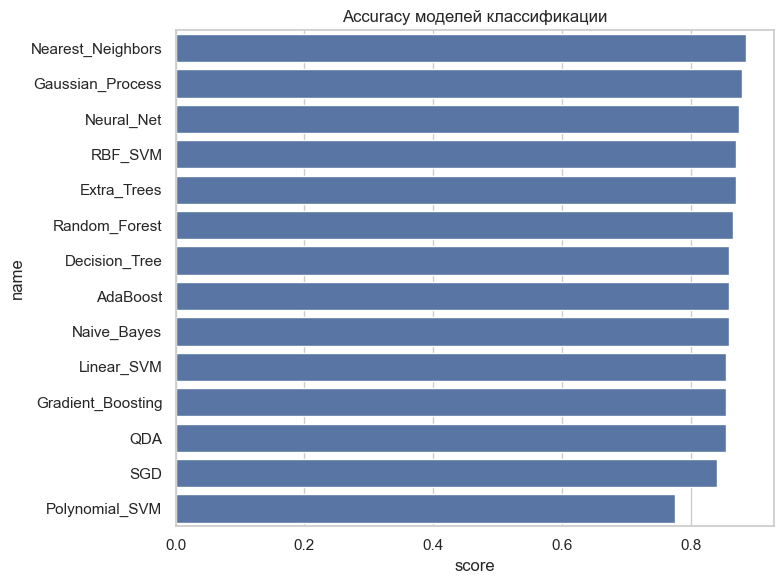

In [5]:
df_models = pd.DataFrame({'name': names, 'score': scores})
df_models.sort_values(by="score", ascending=False, inplace=True)

# Таблица с градиентом
cm = sns.light_palette("green", as_cmap=True)
styled = df_models.style.background_gradient(cmap=cm)
display(styled)

# Барплот
sns.set(style="whitegrid")
plt.figure(figsize=(8,6))
ax = sns.barplot(y="name", x="score", data=df_models)
plt.title("Accuracy моделей классификации")
plt.tight_layout()
plt.show()

In [12]:
import pandas as pd

df_adv = pd.read_csv('Advertising.csv')
print(df_adv.head())
print(df_adv.columns.tolist())

   Unnamed: 0     TV  Radio  Newspaper  Sales
0           1  230.1   37.8       69.2   22.1
1           2   44.5   39.3       45.1   10.4
2           3   17.2   45.9       69.3    9.3
3           4  151.5   41.3       58.5   18.5
4           5  180.8   10.8       58.4   12.9
['Unnamed: 0', 'TV', 'Radio', 'Newspaper', 'Sales']


In [13]:
X = df_adv.drop('Sales', axis=1)
y = df_adv['Sales']

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Данные загружены и подготовлены!")

Данные загружены и подготовлены!


In [16]:
from sklearn.linear_model import ElasticNet

base_elastic = ElasticNet()
param_grid = {'alpha': [0.1, 1, 5, 10, 50, 100],
              'l1_ratio': [0.1, 0.5, 0.7, 0.9, 0.95, 0.99, 1]}

grid_model = GridSearchCV(estimator=base_elastic,
                          param_grid=param_grid,
                          scoring='neg_mean_squared_error',
                          cv=5,
                          verbose=1)

grid_model.fit(X_train, y_train)

print("Лучшие параметры:", grid_model.best_params_)
print("Лучший estimator:", grid_model.best_estimator_)

Fitting 5 folds for each of 42 candidates, totalling 210 fits
Лучшие параметры: {'alpha': 0.1, 'l1_ratio': 1}
Лучший estimator: ElasticNet(alpha=0.1, l1_ratio=1)


In [17]:
y_pred = grid_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f"Среднеквадратичная ошибка на тесте: {mse:.4f}")

Среднеквадратичная ошибка на тесте: 2.4119
